In [1]:
import polars as pl
import datetime
import seaborn as sns
import matplotlib.pyplot as plt
from polars import DataFrame

In [2]:
trans = (
    pl.read_csv('../data/HI-Medium_Trans.csv')
    .with_columns(
        pl.col("Timestamp").str.strptime(pl.Datetime, '%Y/%m/%d %H:%M', strict=True)
    )
    .sort('Timestamp')
)

In [3]:
trans.head()

Timestamp,From Bank,From,To Bank,To,Amount Received,Receiving Currency,Amount Paid,Payment Currency,Payment Format,Is Laundering
datetime[μs],i64,str,i64,str,f64,str,f64,str,str,i64
2022-09-01 00:00:00,1046,"""800A37D90""",274159,"""820C04F20""",26.42,"""US Dollar""",26.42,"""US Dollar""","""Credit Card""",0
2022-09-01 00:00:00,21418,"""800AB4DE0""",21418,"""800AB4DE0""",23.61,"""US Dollar""",23.61,"""US Dollar""","""Reinvestment""",0
2022-09-01 00:00:00,32248,"""80056BBD0""",11,"""800BAFE20""",12373.74,"""US Dollar""",12373.74,"""US Dollar""","""ACH""",0
2022-09-01 00:00:00,11798,"""80145BAF0""",11798,"""80145BAF0""",4981.27,"""US Dollar""",4981.27,"""US Dollar""","""Reinvestment""",0
2022-09-01 00:00:00,1924,"""800CCE420""",1924,"""800CCE420""",22.94,"""US Dollar""",22.94,"""US Dollar""","""Reinvestment""",0


In [4]:
zero = trans['Timestamp'].min()
hundred = trans['Timestamp'].max()

In [5]:
diff = hundred - zero
days = diff.days
sixty = zero + datetime.timedelta(days=days * 0.6)
eighty = zero + datetime.timedelta(days=days * 0.8)
hundred = zero + datetime.timedelta(days=days)

print(zero, sixty, eighty, hundred)

2022-09-01 00:00:00 2022-09-17 04:48:00 2022-09-22 14:24:00 2022-09-28 00:00:00


In [6]:
train = trans.filter(pl.col('Timestamp') <= sixty)
val = trans.filter(pl.col('Timestamp') <= eighty).filter(pl.col('Timestamp') > sixty)
test = trans.filter(pl.col('Timestamp') > eighty)

# Temporal stats

In [7]:
def add_temporal_stats(df: pl.DataFrame, col: str) -> pl.DataFrame:
    return (
        df.select([
            pl.col("Timestamp"),
            pl.col(col),
        ])
        .sort([col, "Timestamp"])
        .with_columns(
            pl.col("Timestamp")
            .diff()
            .over(col)
            .dt.total_seconds()
            .alias("gap")
        )
        .filter(pl.col("gap").is_not_null() & (pl.col("gap") >= 0))
        .group_by(col)
        .agg([
            pl.col("gap").mean().alias(f"avg_gap_{col}"),
            pl.col("gap").var().alias(f"var_gap_{col}"),
        ])
    )

In [8]:
train_temporal_features_from = add_temporal_stats(train, 'From')
train_temporal_features_to = add_temporal_stats(val, 'To')

val_temporal_features_from = add_temporal_stats(val, 'From')
val_temporal_features_to = add_temporal_stats(val, 'To')

test_temporal_features_from = add_temporal_stats(test, 'From')
test_temporal_features_to = add_temporal_stats(test, 'To')

In [9]:
train_temporal_features_from.head()

From,avg_gap_From,var_gap_From
str,f64,f64
"""100428660""",1.283536,75.364763
"""1004286A8""",2.036063,118.018386
"""1004286F0""",6.623765,358.693894
"""100428738""",17.155516,917.852018
"""100428780""",19.346685,1059.100116


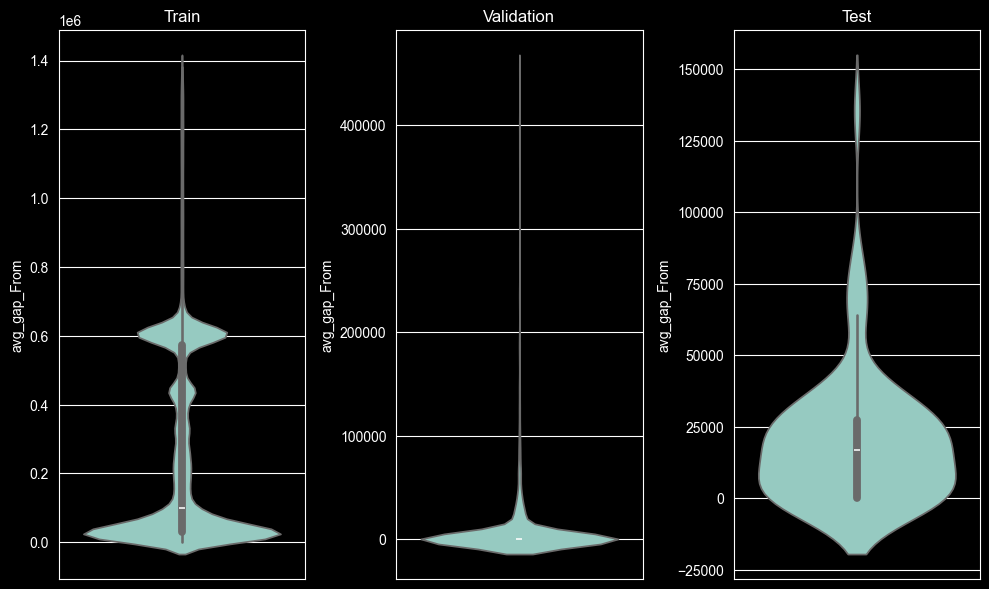

In [10]:
fig, ax = plt.subplots(1, 3, figsize=(10, 6))

sns.violinplot(y=train_temporal_features_from['avg_gap_From'], ax=ax[0])
ax[0].set_title("Train")

sns.violinplot(y=val_temporal_features_from['avg_gap_From'], ax=ax[1])
ax[1].set_title("Validation")

sns.violinplot(y=test_temporal_features_from ['avg_gap_From'], ax=ax[2])
ax[2].set_title("Test")

plt.tight_layout()
plt.show()

# Fraudulent patterns

## 2-cycles

In [23]:
def count_reciprocal_neighbours(df: DataFrame) -> DataFrame:
    df = df.select(
        pl.col('From'),
        pl.col('To'),
    ).unique()

    reciprocal = (
        df.join(df, how='inner', left_on=['From', 'To'], right_on=['To', 'From'], suffix='_r')
        .group_by('From')
        .len()
    )

    return df.select(pl.col('From')).unique().join(reciprocal, on='From', how='left').fill_null(0)

In [24]:
train_2_cycles = count_reciprocal_neighbours(train)

val_2_cycles = count_reciprocal_neighbours(val)

test_2_cycles = count_reciprocal_neighbours(test)

/var/folders/0x/klqdyhpj427dvg81kxzyfcvm0000gn/T/ipykernel_93508/1042352058.py:10: DeprecationWarning: `GroupBy.count` was renamed; use `GroupBy.len` instead
  .count()


In [25]:
train_2_cycles.describe()

statistic,From,count
str,str,f64
"""count""","""2013557""",2.013557e6
"""null_count""","""0""",0.0
"""mean""",null,0.766631
"""std""",null,0.495855
"""min""","""100428660""",0.0
"""25%""",null,0.0
"""50%""",null,1.0
"""75%""",null,1.0
"""max""","""8521FC1B0""",15.0


## Ego profile

In [ ]:
def compute_ego_profiles(df: DataFrame, every: str, period: str) -> DataFrame:
    sorted = (
        df.select(
            pl.col('From'),
            pl.col('To'),
            pl.col('Timestamp'),
        )
        .sort('Timestamp')
    )

    in_feats = (
        sorted
        .group_by_dynamic(
            index_column=pl.col('Timestamp'),
            every=every,
            period=period,
            by=pl.col('From'),
            closed='right'
        ).agg([
            pl.len().alias('deg_out'),
            pl.col('From').unique().alias('fan_out'),
        ])
    )
    out_feats = (
        sorted
        .group_by_dynamic(
            index_column=pl.col('Timestamp'),
            every=every,
            period=period,
            by=pl.col('To'),
            closed='right'
        ).agg([
            pl.len().alias('deg_in'),
            pl.col('To').unique().alias('fan_in'),
        ])
    )

    return in_feats.join(out_feats, left_on='From', right_on='To', how='inner') # TODO: TX Flow imbalance

In [ ]:
train_ego_profile = compute_ego_profiles(train, '1d', '7d')

val_ego_profile = compute_ego_profiles(val, '1d', '7d')

test_ego_profile = compute_ego_profiles(test, '1d', '7d')

# Flow-aware positional prediction

In [ ]:
def compute_flow_aware_positional_pred(df: DataFrame) -> DataFrame:
    pass

In [ ]:
train_pos_pred = compute_flow_aware_positional_pred(train)

val_pos_pred = compute_flow_aware_positional_pred(val)

test_pos_pred = compute_flow_aware_positional_pred(test)